<div style="background:#123B63;color:white;padding:14px 18px;border-radius:6px">
<b>CSE 816 &mdash; Machine Learning Lab</b> &nbsp;&middot;&nbsp; Department of CSE, University of Chittagong<br>
<span style="font-size:90%">Module 1 &middot; Week 3 &middot; Part 3 of 4 &nbsp;&middot;&nbsp; 60 minutes</span>
</div>

# Gradient Descent for Logistic Regression

Model from Part 1, cost from Part 2. This part fits them, and then does the thing the previous
two parts kept deferring: turns a probability into a decision.

The gradient is going to look *exactly* like the one you wrote in Week 2. Resist the
conclusion that it is the same algorithm; section 4 spells out what actually differs.

**Companion theory lecture:** CSE 815, Week 3, Part 1 (Gradient Descent for Logistic
Regression).

## What you will be able to do

1. Derive the logistic gradient in code, first with an explicit loop and then vectorised, and
   prove the two agree.
2. Check any gradient you write against a finite-difference estimate before trusting it.
3. Train a logistic model, and explain why feature scaling matters as much here as in Week 2.
4. State precisely what logistic regression shares with linear regression, and what it does not.
5. Build a confusion matrix, compute precision and recall, and choose a threshold from the
   relative cost of the two errors rather than accepting `0.5`.
6. Reproduce your result with `scikit-learn`.

---

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

np.set_printoptions(precision=4, suppress=True)

BLUE, TEAL, AMBER, ROSE, GRAY = "#123B63", "#1B7F79", "#C97B17", "#9B2C4B", "#4A5560"


def sigmoid(z):
    """Numerically stable sigmoid; from Part 1."""
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out[()] if out.ndim == 0 else out


def compute_cost(X, y, w, b, eps=1e-12):
    """Average logistic loss; from Part 2. The clip is load-bearing."""
    f = np.clip(sigmoid(X @ w + b), eps, 1 - eps)
    return float(-np.mean(y * np.log(f) + (1 - y) * np.log(1 - f)))


def zscore(X):
    """Z-score normalization; from Week 2. Returns the scaled matrix and the statistics."""
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    return (X - mu) / sigma, mu, sigma


def load_loans(seed=816, m=120):
    rng = np.random.default_rng(seed)
    income = np.round(rng.uniform(12, 90, m), 1)
    debt = np.round(rng.uniform(2, 58, m), 1)
    z = 0.105 * (income - 42.0) - 0.125 * (debt - 28.0)
    y = (rng.random(m) < 1.0 / (1.0 + np.exp(-z))).astype(float)
    return np.column_stack([income, debt]), y


def load_screening():
    """Eight patients: tumour diameter (cm), 1 = malignant."""
    return np.arange(1.0, 9.0).reshape(-1, 1), np.array([0., 1, 0, 0, 0, 1, 1, 1])


def load_lecture():
    """The four points the lecture works through by hand: x = 1,2,3,4 and y = 0,0,1,1."""
    return np.array([[1.], [2.], [3.], [4.]]), np.array([0., 0, 1, 1])


X_loan, y_loan = load_loans()
X_scr, y_scr = load_screening()
X_lec, y_lec = load_lecture()
m, n = X_loan.shape
print(f"loans: m = {m}, n = {n}")

loans: m = 120, n = 2


---

## 2. The gradient

From the lecture: the derivative of the loss with respect to $z$ is $f - y$ in **both** cases,
$y=0$ and $y=1$. The sigmoid's derivative in the numerator cancels the logarithm's in the
denominator. Everything else is the chain rule:

$$\frac{\partial J}{\partial w_j} = \frac1m\sum_{i=1}^m \bigl(f^{(i)} - y^{(i)}\bigr)x^{(i)}_j,
\qquad
\frac{\partial J}{\partial b} = \frac1m\sum_{i=1}^m \bigl(f^{(i)} - y^{(i)}\bigr)$$

Write it twice, as in Week 2: once so you can see it, once so it runs.

In [2]:
def compute_gradient_loop(X, y, w, b):
    """One example at a time, one feature at a time. Slow, and unambiguous."""
    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0
    for i in range(m):
        z_i = 0.0
        for j in range(n):
            z_i += w[j] * X[i, j]
        f_i = sigmoid(np.array(z_i + b))
        err_i = f_i - y[i]
        for j in range(n):
            dj_dw[j] += err_i * X[i, j]
        dj_db += err_i
    return dj_dw / m, dj_db / m


def compute_gradient(X, y, w, b):
    """The same thing, vectorised. This is the one to use."""
    err = sigmoid(X @ w + b) - y
    return X.T @ err / len(y), float(err.mean())


rng = np.random.default_rng(0)
w_test, b_test = rng.normal(0, 0.1, n), 0.3

gw_loop, gb_loop = compute_gradient_loop(X_loan, y_loan, w_test, b_test)
gw_vec, gb_vec = compute_gradient(X_loan, y_loan, w_test, b_test)

print("loop      :", gw_loop, " db =", gb_loop)
print("vectorised:", gw_vec, " db =", gb_vec)

assert np.allclose(gw_loop, gw_vec)
assert np.isclose(gb_loop, gb_vec)
print("\nIdentical, as they must be.")

loop      : [0.7633 6.7317]  db = 0.09971246524507987
vectorised: [0.7633 6.7317]  db = 0.09971246524507989

Identical, as they must be.


Compare that with Week 2's `compute_gradient` for linear regression:

```python
err = X @ w + b - y          # linear regression
err = sigmoid(X @ w + b) - y # logistic regression
```

One line differs. Section 4 explains why that is a real fact about these two models and not a
coincidence, and why it still does **not** make them the same algorithm.

---

## 3. Check the gradient before you trust it

A wrong gradient does not raise an exception. It produces a cost curve that decreases slowly,
or plateaus, or diverges &mdash; symptoms indistinguishable from a bad learning rate. Check it
numerically, every time, on a small case.

In [3]:
def gradient_check(X, y, w, b, h=1e-6):
    """Compare the analytic gradient with a central finite difference, component by
    component. Returns the largest relative discrepancy."""
    gw, gb = compute_gradient(X, y, w, b)

    num_w = np.zeros_like(w)
    for j in range(len(w)):
        step = np.zeros_like(w)
        step[j] = h
        num_w[j] = (compute_cost(X, y, w + step, b) - compute_cost(X, y, w - step, b)) / (2 * h)
    num_b = (compute_cost(X, y, w, b + h) - compute_cost(X, y, w, b - h)) / (2 * h)

    analytic = np.r_[gw, gb]
    numeric = np.r_[num_w, num_b]
    scale = np.maximum(np.abs(analytic) + np.abs(numeric), 1e-12)
    return float(np.max(np.abs(analytic - numeric) / scale)), analytic, numeric


rel, analytic, numeric = gradient_check(X_loan, y_loan, w_test, b_test)
print("analytic:", analytic)
print("numeric :", numeric)
print(f"\nlargest relative discrepancy: {rel:.3e}")

assert rel < 1e-6, "the analytic gradient disagrees with the numerical one"
print("Gradient verified.")

analytic: [0.7633 6.7317 0.0997]
numeric : [0.7633 6.7317 0.0997]

largest relative discrepancy: 1.507e-09
Gradient verified.


In [4]:
# What a *wrong* gradient looks like under the same test -- here, a forgotten sigmoid.
def compute_gradient_buggy(X, y, w, b):
    err = (X @ w + b) - y          # linear regression's residual, by mistake
    return X.T @ err / len(y), float(err.mean())


gw_bug, gb_bug = compute_gradient_buggy(X_loan, y_loan, w_test, b_test)
print("buggy analytic:", np.r_[gw_bug, gb_bug])
print("numeric       :", numeric)
print("\nThe check catches it immediately. Without the check, this bug costs you an")
print("afternoon of tuning alpha.")

assert not np.allclose(np.r_[gw_bug, gb_bug], numeric)

buggy analytic: [1.0714 0.7826 0.0012]
numeric       : [0.7633 6.7317 0.0997]

The check catches it immediately. Without the check, this bug costs you an
afternoon of tuning alpha.


---

## 4. Same update rule, different algorithm

The formula is shared, and the reason is real: both costs come from a probabilistic model in
the same family, and in both the derivative of the loss with respect to $z$ works out to
$f - y$. But a shared *gradient formula* is not a shared algorithm.

| | linear regression | logistic regression |
|---|---|---|
| $f$ | $\mathbf{w}\cdot\mathbf{x}+b$ | $g(\mathbf{w}\cdot\mathbf{x}+b)$ |
| range of $f$ | all of $\mathbb{R}$ | $(0,1)$ |
| cost $J$ | squared error | logistic loss |
| $J$ is | quadratic and convex | convex, **not** quadratic |
| closed form | the normal equation | **none exists** |
| output means | the predicted value | $\mathbb{P}(y=1\mid\mathbf{x})$ |

The row that bites is the last but one. In Week 2 you could always check gradient descent
against `np.linalg.lstsq`. Here there is no such check, because setting $\nabla J = 0$ gives a
system of transcendental equations with no solution in elementary functions. **Iteration is not
a convenience; it is the only option.**

---

## 5. Gradient descent

In [5]:
def gradient_descent(X, y, alpha, num_iters, w_init=None, b_init=0.0, record_every=1):
    """Batch gradient descent on the logistic cost. Same shape as Week 2's, and the
    same simultaneous update."""
    w = np.zeros(X.shape[1]) if w_init is None else np.array(w_init, dtype=float)
    b = float(b_init)
    history = {"cost": [], "iter": []}
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw           # simultaneous: both use the OLD w, b
        b = b - alpha * dj_db
        if i % record_every == 0 or i == num_iters - 1:
            history["cost"].append(compute_cost(X, y, w, b))
            history["iter"].append(i)
    return w, b, history


# Start where every logistic model starts: J = ln 2.
print(f"J at the origin: {compute_cost(X_loan, y_loan, np.zeros(n), 0.0):.6f}   (ln 2 = {np.log(2):.6f})")

J at the origin: 0.693147   (ln 2 = 0.693147)


### First try: raw features

Week 2's lesson has not been repealed. Income runs to 90 and debt to 58, so the cost surface is
a long thin trough, and the largest usable step is tiny.

The stability limit is $\alpha < 2/\lambda_{\max}$, where $\lambda_{\max}$ is the largest
eigenvalue of the Hessian. For the logistic cost the Hessian is

$$H = \frac1m\sum_i f^{(i)}\bigl(1-f^{(i)}\bigr)\,\tilde{\mathbf{x}}^{(i)}
      \bigl(\tilde{\mathbf{x}}^{(i)}\bigr)^{\mathsf{T}},
      \qquad \tilde{\mathbf{x}} = (\mathbf{x}, 1)$$

which is the same $\tilde{X}^{\mathsf{T}}\tilde{X}/m$ as before, weighted by $f(1-f)$.

In [6]:
def curvature(X, y, w, b):
    """Eigenvalues of the logistic Hessian, and the resulting limit on alpha."""
    A = np.column_stack([X, np.ones(len(y))])
    d = sigmoid(X @ w + b)
    d = d * (1 - d)
    H = A.T @ (A * d[:, None]) / len(y)
    ev = np.linalg.eigvalsh(H)
    return ev.min(), ev.max(), 2.0 / ev.max(), ev.max() / ev.min()


X_z, mu, sigma = zscore(X_loan)

print(f"{'features':>12} {'lambda_min':>12} {'lambda_max':>12} {'kappa':>12} {'alpha_max':>11}")
print("-" * 62)
for name, M in [("raw", X_loan), ("z-scored", X_z)]:
    lo, hi, a_max, kappa = curvature(M, y_loan, np.zeros(n), 0.0)
    print(f"{name:>12} {lo:12.6f} {hi:12.4f} {kappa:12.1f} {a_max:11.5f}")

print("\nAt the origin every f = 1/2, so every weight f(1-f) is exactly 1/4 and the")
print("Hessian is a quarter of Week 2's. The conditioning problem is identical.")

    features   lambda_min   lambda_max        kappa   alpha_max
--------------------------------------------------------------
         raw     0.024225     901.0224      37194.2     0.00222
    z-scored     0.219265       0.2807          1.3     7.12417

At the origin every f = 1/2, so every weight f(1-f) is exactly 1/4 and the
Hessian is a quarter of Week 2's. The conditioning problem is identical.


In [7]:
# Both runs use 90% of their own stability limit, and stop when the gradient is small.
def run_to_convergence(X, y, alpha, tol=1e-6, cap=500_000):
    w, b = np.zeros(X.shape[1]), 0.0
    for k in range(1, cap + 1):
        gw, gb = compute_gradient(X, y, w, b)
        w, b = w - alpha * gw, b - alpha * gb
        if np.linalg.norm(np.r_[gw, gb]) < tol:
            return w, b, k
    return w, b, cap


print(f"{'features':>12} {'alpha':>10} {'iterations':>12} {'J':>10}")
print("-" * 48)
results = {}
for name, M in [("raw", X_loan), ("z-scored", X_z)]:
    _, hi, a_max, _ = curvature(M, y_loan, np.zeros(n), 0.0)
    alpha = 0.9 * a_max
    w_fit, b_fit, iters = run_to_convergence(M, y_loan, alpha)
    results[name] = (w_fit, b_fit, iters)
    print(f"{name:>12} {alpha:10.5f} {iters:12,} {compute_cost(M, y_loan, w_fit, b_fit):10.6f}")

speedup = results["raw"][2] / results["z-scored"][2]
print(f"\nSame answer, {speedup:,.0f} times fewer iterations.")

assert results["z-scored"][2] < results["raw"][2] / 100

    features      alpha   iterations          J
------------------------------------------------
         raw    0.00200      314,300   0.308059
    z-scored    6.41175           69   0.308059

Same answer, 4,555 times fewer iterations.


Both runs reach the same cost, `0.308059`. Scaling changed the path, not the destination
&mdash; exactly as in Week 2. From here on, scale.

### The fit, and reading it back in real units

Scaled weights are per standard deviation. Convert them back the same way as Week 2:
$w_j^{\text{raw}} = w_j/\sigma_j$ and $b^{\text{raw}} = b - \sum_j w_j\mu_j/\sigma_j$.

In [8]:
w_z, b_z, hist = gradient_descent(X_z, y_loan, alpha=1.0, num_iters=20000, record_every=50)

w_raw = w_z / sigma
b_raw = b_z - np.sum(w_z * mu / sigma)

print(f"scaled  : w = {w_z},  b = {b_z:.6f}")
print(f"raw     : w = {w_raw},  b = {b_raw:.6f}")
print(f"J       : {compute_cost(X_z, y_loan, w_z, b_z):.6f}")

# Predictions must be identical on either scale.
assert np.allclose(sigmoid(X_z @ w_z + b_z), sigmoid(X_loan @ w_raw + b_raw))
print("\nPredictions agree on both scales, to machine precision.")

FEATURES = ["income (k BDT)", "debt (% of income)"]
print(f"\n{'feature':22} {'scaled w':>10} {'raw w':>12} {'odds factor':>14}")
print("-" * 62)
for j in range(n):
    print(f"{FEATURES[j]:22} {w_z[j]:10.4f} {w_raw[j]:12.6f} {np.exp(w_raw[j]):14.4f}")

print("\nRead the last column as: one more thousand BDT of monthly income multiplies the")
print(f"odds of repayment by {np.exp(w_raw[0]):.4f}; one more percentage point of debt service")
print(f"multiplies them by {np.exp(w_raw[1]):.4f}, i.e. divides them by {1/np.exp(w_raw[1]):.4f}.")

scaled  : w = [ 2.2342 -2.4892],  b = 0.217076
raw     : w = [ 0.102  -0.1541],  b = -0.247718
J       : 0.308059

Predictions agree on both scales, to machine precision.

feature                  scaled w        raw w    odds factor
--------------------------------------------------------------
income (k BDT)             2.2342     0.101998         1.1074
debt (% of income)        -2.4892    -0.154147         0.8571

Read the last column as: one more thousand BDT of monthly income multiplies the
odds of repayment by 1.1074; one more percentage point of debt service
multiplies them by 0.8571, i.e. divides them by 1.1667.


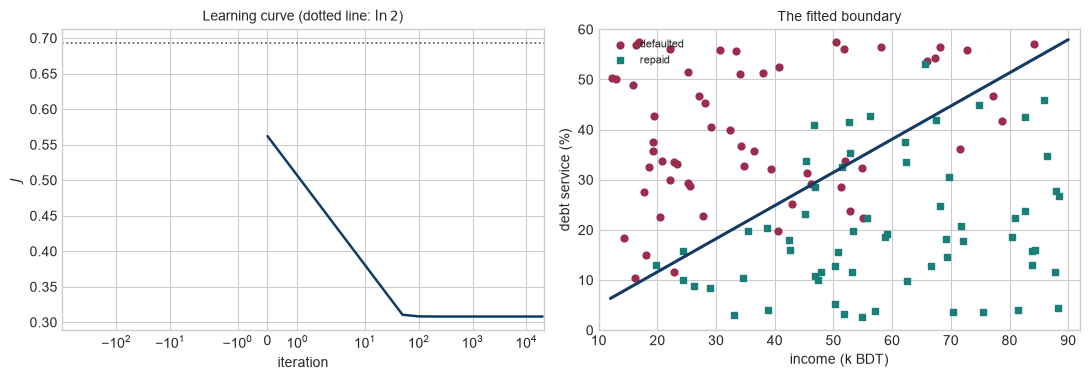

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))

axes[0].plot(hist["iter"], hist["cost"], c=BLUE, lw=1.8)
axes[0].axhline(np.log(2), c=GRAY, ls=":", lw=1.2)
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("$J$")
axes[0].set_title("Learning curve (dotted line: $\\ln 2$)", fontsize=10)
axes[0].set_xscale("symlog")

x1 = np.array([12.0, 90.0])
for label, colour, marker, name in [(0.0, ROSE, "o", "defaulted"), (1.0, TEAL, "s", "repaid")]:
    sel = y_loan == label
    axes[1].scatter(X_loan[sel, 0], X_loan[sel, 1], c=colour, marker=marker, s=24, label=name)
axes[1].plot(x1, (-b_raw - w_raw[0] * x1) / w_raw[1], c=BLUE, lw=2.2)
axes[1].set_xlim(10, 92)
axes[1].set_ylim(0, 60)
axes[1].set_xlabel("income (k BDT)")
axes[1].set_ylabel("debt service (%)")
axes[1].set_title("The fitted boundary", fontsize=10)
axes[1].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Checkpoint 1

Reproduce the four iterations the lecture works through on the board, using `X_lec`, `y_lec`
(that is, $x = 1,2,3,4$ and $y = 0,0,1,1$) with `alpha = 0.5` from `w = 0`, `b = 0`.

Print a table with one row per iteration showing $\partial J/\partial w$,
$\partial J/\partial b$, $w$, $b$ and $J$, to four decimal places.

*Expected:* the lecture's table exactly &mdash;

| iter | $\partial J/\partial w$ | $\partial J/\partial b$ | $w$ | $b$ | $J$ |
|---|---|---|---|---|---|
| 0 | --- | --- | 0.0000 | 0.0000 | 0.6931 |
| 1 | -0.5000 | +0.0000 | 0.2500 | 0.0000 | 0.6250 |
| 2 | -0.0578 | +0.1487 | 0.2789 | -0.0744 | 0.6124 |
| 3 | -0.0525 | +0.1476 | 0.3051 | -0.1482 | 0.6003 |
| 4 | -0.0512 | +0.1452 | 0.3307 | -0.2207 | 0.5885 |

Then answer two questions. Why is $\partial J/\partial b$ exactly zero at the first step?
And after four steps the boundary $-b/w$ sits at `0.6674`, nowhere near the sensible `2.5`
&mdash; is that a bug, a bad $\alpha$, or neither?

In [10]:
# Your code here

---

## 6. From probability to decision: the threshold

Everything so far produced a **probability**. A lending officer needs a **decision**, and that
needs a threshold. `0.5` has been used throughout without an argument, and there is none: it is
the value at which the two classes are equally probable, which makes it the right choice only
when the two kinds of mistake cost the same.

The two mistakes have names, and on this data they fall on different people.

- A **false positive** is a borrower predicted to repay who defaults &mdash; the lender loses
  the principal.
- A **false negative** is a borrower predicted to default who would have repaid &mdash; the
  lender loses a customer, and the customer loses the loan.

In [11]:
def confusion(y, p, threshold=0.5):
    """Returns TP, FP, FN, TN for a given threshold."""
    pred = p >= threshold
    TP = int(np.sum(pred & (y == 1)))
    FP = int(np.sum(pred & (y == 0)))
    FN = int(np.sum(~pred & (y == 1)))
    TN = int(np.sum(~pred & (y == 0)))
    return TP, FP, FN, TN


p_loan = sigmoid(X_z @ w_z + b_z)

TP, FP, FN, TN = confusion(y_loan, p_loan, 0.5)
print("at threshold 0.5")
print(f"                    predicted 0   predicted 1")
print(f"  actually 0 (bad)  {TN:11d}   {FP:11d}")
print(f"  actually 1 (good) {FN:11d}   {TP:11d}")

assert TP + FP + FN + TN == len(y_loan)
print(f"\n  accuracy  = (TP + TN) / m = {(TP + TN) / len(y_loan):.4f}")
print(f"  precision = TP / (TP + FP) = {TP / (TP + FP):.4f}")
print(f"  recall    = TP / (TP + FN) = {TP / (TP + FN):.4f}")

at threshold 0.5
                    predicted 0   predicted 1
  actually 0 (bad)           47            10
  actually 1 (good)           9            54

  accuracy  = (TP + TN) / m = 0.8417
  precision = TP / (TP + FP) = 0.8438
  recall    = TP / (TP + FN) = 0.8571


In [12]:
print(f"{'threshold':>10} {'TP':>4} {'FP':>4} {'FN':>4} {'TN':>4} "
      f"{'accuracy':>10} {'precision':>11} {'recall':>9}")
print("-" * 62)
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    TP, FP, FN, TN = confusion(y_loan, p_loan, t)
    prec = TP / (TP + FP) if TP + FP else float("nan")
    print(f"{t:10.2f} {TP:4d} {FP:4d} {FN:4d} {TN:4d} "
          f"{(TP + TN) / len(y_loan):10.4f} {prec:11.4f} {TP / (TP + FN):9.4f}")

print("\nRaising the threshold can only lower recall -- that one is guaranteed, since")
print("the set of positive predictions only shrinks. Precision usually rises but is")
print("not guaranteed to. Accuracy is monotone in neither direction, and 0.5 does")
print("not maximise it here: 0.40 does.")

 threshold   TP   FP   FN   TN   accuracy   precision    recall
--------------------------------------------------------------
      0.20   61   18    2   39     0.8333      0.7722    0.9683
      0.30   59   16    4   41     0.8333      0.7867    0.9365
      0.40   58   13    5   44     0.8500      0.8169    0.9206
      0.50   54   10    9   47     0.8417      0.8438    0.8571
      0.60   50    6   13   51     0.8417      0.8929    0.7937
      0.70   46    5   17   52     0.8167      0.9020    0.7302
      0.80   43    3   20   54     0.8083      0.9348    0.6825

Raising the threshold can only lower recall -- that one is guaranteed, since
the set of positive predictions only shrinks. Precision usually rises but is
not guaranteed to. Accuracy is monotone in neither direction, and 0.5 does
not maximise it here: 0.40 does.


### Choosing the threshold from the cost of the errors

Suppose the lender judges one default as bad as five refused good customers. Then the quantity
to minimise is not the error *count* but

$$5 \times \text{FP} + 1 \times \text{FN}$$

Sweep the threshold and minimise it. Nothing about the model changes; only the decision rule
does, and it can be changed after deployment without retraining.

 threshold   FP   FN   5*FP + FN
----------------------------------
     0.300   16    4          84
     0.500   10    9          59
     0.700    5   17          42
     0.800    3   20          35
     0.875    0   25          25   <-- minimum
     0.900    0   28          28
     0.950    0   36          36

The cost-minimising threshold is 0.875, not 0.5.
At 0.5 the lender books 10 defaults; at the chosen threshold, none -- at the
price of refusing many customers who would have repaid.


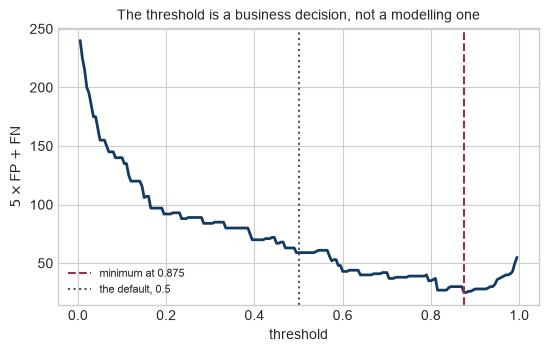

In [13]:
thresholds = np.arange(0.005, 1.0, 0.005)
costs = np.array([5 * confusion(y_loan, p_loan, t)[1] + confusion(y_loan, p_loan, t)[2]
                  for t in thresholds])
best_t = thresholds[costs.argmin()]

print(f"{'threshold':>10} {'FP':>4} {'FN':>4} {'5*FP + FN':>11}")
print("-" * 34)
for t in [0.3, 0.5, 0.7, 0.8, best_t, 0.9, 0.95]:
    TP, FP, FN, TN = confusion(y_loan, p_loan, t)
    mark = "   <-- minimum" if np.isclose(t, best_t) else ""
    print(f"{t:10.3f} {FP:4d} {FN:4d} {5 * FP + FN:11d}{mark}")

print(f"\nThe cost-minimising threshold is {best_t:.3f}, not 0.5.")
print("At 0.5 the lender books 10 defaults; at the chosen threshold, none -- at the")
print("price of refusing many customers who would have repaid.")

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(thresholds, costs, c=BLUE, lw=2.0)
ax.axvline(best_t, c=ROSE, ls="--", lw=1.5, label=f"minimum at {best_t:.3f}")
ax.axvline(0.5, c=GRAY, ls=":", lw=1.5, label="the default, 0.5")
ax.set_xlabel("threshold")
ax.set_ylabel("$5\\times$FP $+$ FN")
ax.set_title("The threshold is a business decision, not a modelling one", fontsize=10)
ax.legend(fontsize=8)
plt.show()

> **Keep the model and the decision rule apart.** Fitting produces a probability; the threshold
> encodes the relative cost of the two errors, which is a matter for the people who bear them.
> A threshold recorded only as the literal `0.5` in somebody's source code is a policy nobody
> can audit &mdash; and here, as the sweep shows, it is not even the policy the lender wanted.
>
> The same reasoning applies with the signs reversed in medical screening, where the expensive
> error is the missed disease. Week 6 returns to this with the metrics for heavily imbalanced
> classes, where accuracy stops being informative altogether.

---

## 7. Checking against scikit-learn

`LogisticRegression` regularizes by default &mdash; that is Part 4's subject. To compare
like with like, turn the penalty down to nothing with a very large `C`.

In [14]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(C=1e10, max_iter=20000)
clf.fit(X_z, y_loan)

print(f"{'':10} {'w1':>12} {'w2':>12} {'b':>12}")
print("-" * 50)
print(f"{'mine':10} {w_z[0]:12.6f} {w_z[1]:12.6f} {b_z:12.6f}")
print(f"{'sklearn':10} {clf.coef_[0, 0]:12.6f} {clf.coef_[0, 1]:12.6f} {clf.intercept_[0]:12.6f}")

print(f"\nlargest difference: {np.abs(np.r_[clf.coef_[0], clf.intercept_[0]] - np.r_[w_z, b_z]).max():.2e}")
print(f"accuracy  mine {(  (p_loan >= 0.5) == y_loan).mean():.4f}   sklearn {clf.score(X_z, y_loan):.4f}")

assert np.allclose(clf.coef_[0], w_z, atol=1e-2)
assert np.isclose(clf.intercept_[0], b_z, atol=1e-2)
print("\nYour implementation and the library agree.")

                     w1           w2            b
--------------------------------------------------
mine           2.234236    -2.489196     0.217076
sklearn        2.232587    -2.487732     0.216481

largest difference: 1.65e-03
accuracy  mine 0.8417   sklearn 0.8417

Your implementation and the library agree.


In [15]:
# predict_proba returns a column per class: column 1 is P(y = 1).
p_sklearn = clf.predict_proba(X_z)[:, 1]
print("max |p_mine - p_sklearn| =", np.abs(p_loan - p_sklearn).max())

# And .predict() is exactly a 0.5 threshold on that column -- nothing more.
assert np.array_equal(clf.predict(X_z), (p_sklearn >= 0.5).astype(float))
print("\nclf.predict() is precisely `predict_proba()[:, 1] >= 0.5`.")
print("If 0.5 is not your threshold, do not use .predict(). Threshold the probability")
print("yourself, with the number your cost analysis chose.")

max |p_mine - p_sklearn| = 0.0002928887146992354

clf.predict() is precisely `predict_proba()[:, 1] >= 0.5`.
If 0.5 is not your threshold, do not use .predict(). Threshold the probability
yourself, with the number your cost analysis chose.


### Checkpoint 2

An applicant earns **35 k BDT** a month with debt service at **20%** of income.

1. Scale that applicant with the **stored** `mu` and `sigma` &mdash; not with statistics
   recomputed from anything &mdash; and report the model's probability of repayment.
2. Report the decision at threshold `0.5` and at the cost-minimising threshold from section 6.
3. Find, by a search over a grid, the income at which this applicant would cross the
   cost-minimising threshold with their debt service unchanged.

*Expected:* probability about `0.5595`; approved at `0.5`, refused at the cost-minimising
threshold of `0.875`; the crossing income is about `51.7` k BDT.

In [16]:
# Your code here

---

## 8. Recap

- The logistic gradient is $\frac1m X^{\mathsf{T}}(\mathbf{f}-\mathbf{y})$ with
  $\mathbf{f} = g(X\mathbf{w}+b)$: the same expression as linear regression with a different
  $\mathbf{f}$.
- Same formula, different algorithm. There is **no** normal equation for logistic regression,
  so there is no closed form to check gradient descent against. Check the gradient instead.
- Always gradient-check. A missing `sigmoid` produces a plausible-looking wrong answer and no
  error message.
- Scaling matters as much as in Week 2: on this data $\kappa$ falls from about `37,000` to
  `1.3`, and the run from about `314,000` iterations to `69`.
- $J = \ln 2$ at the origin, always. It is the number to beat.
- Convert scaled weights back with $w_j/\sigma_j$ before quoting them, and read $e^{w_j}$ as
  the factor by which one unit of $x_j$ multiplies the odds.
- The threshold is not part of the fit. Choose it from the relative cost of a false positive
  and a false negative; here that gave a threshold far above `0.5`.
- `sklearn`'s `.predict()` hard-codes `0.5`. Use `predict_proba` and threshold it yourself.

### Exercises to hand in

1. Run `gradient_descent` on the raw features with `alpha = 0.0025`, just above the stability
   limit you computed, for 200 iterations. Plot the cost history and describe precisely what
   goes wrong.
2. Time `compute_gradient_loop` against `compute_gradient` on `load_loans(m=20000)`. Report the
   speed-up, and compare it with the figure you measured in Week 2, Part 1.
3. Add a third feature to the loans data: `income * (1 - debt/100)`, the money left after debt
   service. Refit and report the change in $J$ and in accuracy. Is the feature worth keeping?
4. Plot precision against recall as the threshold sweeps from 0 to 1. Mark the points for
   thresholds `0.3`, `0.5` and `0.8`. Which end of this curve would a microfinance lender
   operate at, and which end a screening programme?
5. Repeat section 6's cost analysis with the weights reversed &mdash; one refused good customer
   as bad as five defaults. Report the new threshold and explain the direction of the change.
6. Split the loans data 80/20, fit on the 80, and produce the threshold sweep on the held-out
   20. Compare the cost-minimising threshold with the one chosen on the training data, and say
   which you would deploy.

### Next

**Part 4 &mdash; Overfitting and Regularization:** what happens when the model has more
flexibility than the data can support, how to see it coming, and the penalty term that is the
standard defence.

**Reading:** James et al., *ISL* 2e, &sect;4.3.2&ndash;4.3.3 (estimation and prediction);
&sect;4.4.2 for the confusion matrix and the threshold.